# Programa para la obtención de la velocidad de eyección del jet

1) Se realiza un ajuste por mínimos cuadrados de los datos de $K$ obtenidos en función de la velocidad de giro obtenida mediante el acelerómetro a una recta, cuya pendiente se trata de la velocidad de eyección del fluido. 
La incertidumbre asociada a $K$ proporcionada por el programa ajuste chorro se ha infraestimado, por lo que el ajuste sea más solido estadísticamente, el programa incluye el cálculo, mediante el método de la bisección, de la incertidumbre interna de K que produce una $\chi^2_{\nu}=1$. De forma que la incertidumbre total de K se trata de $\sigma_{total}=\sqrt{\sigma_K^2+\sigma_{int}^2}$ con la cual se ha realizado el ajuste.\\

2) El programa devuelve los parámetros a y b de la recta ajustada ($y=ax+b$), asi como el valor de la incertidumbre interna de K y el coeficiente de pearson $r$, además de una repesentación gráfica del ajuste realizado\\

3) El fichero de entrada he de contener: la primera columa ha de ser la inversa de la velocidad angular (s), la segunda columna el valor de K (cm),  la tercera columna la incertidumbre en la inversa de la velocidad angular (s) y la cuarta columna la incertidumbre en K (cm).



sigma_int = 3.53374690
a = 231.34207133 ± 3.81944483 (cm/s)
b = -0.98537018 ± 1.03951320 (cm)
chi2 = 10.000000
chi2 reducido = 1.000000
r (Pearson) = 0.998655


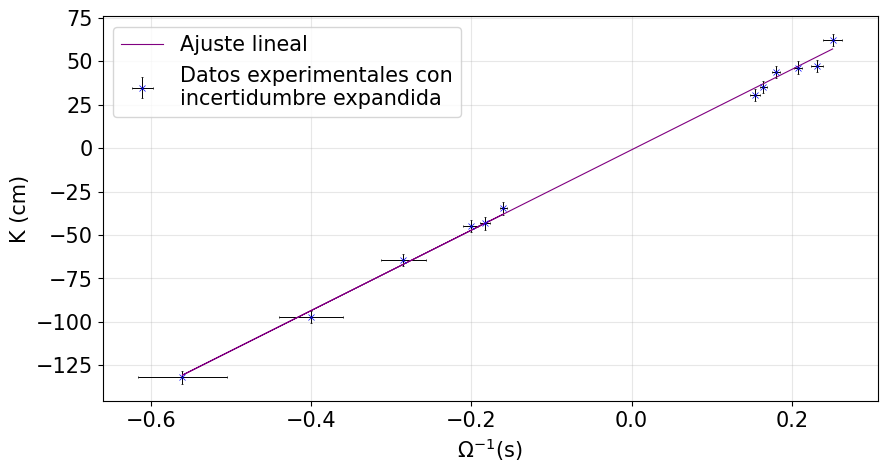

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

#######################################################################################################################################################
# #######################Introduzca el nombre del fichero de K en función de la inversa de la velocidad angular########################################
# #####################################################################################################################################################



datos = np.loadtxt("w_K_28_05.txt", skiprows = 1)

# Extraigo las columnas de la matriz datos

inversa_w = datos[:, 0]
K = datos[:, 1]
inc_w = datos[:, 2]
Inc_K = datos[:, 3]

# Grados de libertad
g_l = len(K) - 2


#Función que busca la incertidumbre interna sigma_int tal que chi^2 reducido sea uno, calcula la nueva incertidumbre total de K,
#realiza el ajuste lineal entre K y la inversa de la velocidad angular usando esta incertidumbre total, 
# y devuelve los parámetros del ajuste (a, b), sus incertidumbres (inc_a, inc_b) y el valor de chi^2 y chi^2 reducido para ese sigma_int.
# y el coeficiente de pearson


def ajuste(sigma_int):
    
    #Devuelvo (a, b, inc_a, inc_b, chi2, chi2_reducido) para un sigma_int dado

    sigma_total = np.sqrt(Inc_K**2 + sigma_int**2)
    pesos = 1.0 / sigma_total
    coef, cov = np.polyfit(inversa_w, K, deg=1, w=pesos, cov=True)
    a, b = coef
    inc_a, inc_b = np.sqrt(np.diag(cov))
    K_modelo = a * inversa_w + b
    chi2 = np.sum(((K - K_modelo) / sigma_total) ** 2)
    chi2_reducido = chi2 / g_l
    return a, b, inc_a, inc_b, chi2, chi2_reducido



#  Si ya es <= 1 con sigma_int = 0, no hace falta sumar incertidumbre interna
a0, b0, inc_a0, inc_b0, chi20, chi2_red0 = ajuste(0.0)

if chi2_red0 <= 1.0:
    sigma_int = 0.0
    a, b, inc_a, inc_b, chi2, chi2_reducido = a0, b0, inc_a0, inc_b0, chi20, chi2_red0

else:
    # Busqueda por biseccion de sigma_int tal que chi2_reducido = 1
    izquierda, derecha = 0.0, np.max(Inc_K)

    # Garantizamos que un extremo (izq) tenga chi2_reducido > 1 y el otro (der) < 1, la solución tiene que estar en ese intervalo
    while ajuste(derecha)[-1] > 1.0:
        derecha *= 2.0

    tol = 1e-8
    max_iter = 200

    for i in range(max_iter):

        mid = 0.5 * (izquierda + derecha)
        chi2_red_mid = ajuste(mid)[-1]

        if abs(chi2_red_mid - 1.0) < tol:
            break

        if chi2_red_mid > 1.0:
            izquierda = mid

        else:
            derecha = mid

    sigma_int = 0.5 * (izquierda + derecha)
    a, b, inc_a, inc_b, chi2, chi2_reducido = ajuste(sigma_int)

# Calculo el coeficiente de Pearson entre K e inversa_w

r = np.corrcoef(inversa_w, K)[0, 1]

#*********************Representación del ajuste lineal con incertidumbre espandida*************************************


fig, ax = plt.subplots(figsize=(10, 5))
ax.set_xlabel(r'$\Omega^{-1}(\mathrm{s})$', fontsize=15)
ax.set_ylabel(r"K (cm)", fontsize=15)
ax.tick_params(axis="both", labelsize=15)

# Calculo la incertidumbre total 
sigma_total_final = np.sqrt(Inc_K**2 + sigma_int**2)

# Grafico las barras de error con la incertidumbre total
ax.errorbar(inversa_w, K, fmt = "x", markeredgewidth=0.5, markersize = 5, color = "blue", xerr = inc_w, yerr = sigma_total_final, ecolor = "black", elinewidth = 0.7, capsize = 1, capthick = 0.7, label = "Datos experimentales con\nincertidumbre expandida")

# Grafico la recta de ajuste
K_ajuste = a * inversa_w + b
ax.plot(inversa_w, K_ajuste, color="purple", linewidth=0.8, label="Ajuste lineal")
ax.grid(alpha=0.3)
ax.legend(loc="upper left", fontsize=15)

# Escribo los resultados por pantalla
print(f"sigma_int = {sigma_int:.8f}")
print(f"a = {a:.8f} ± {inc_a:.8f} (cm/s)")
print(f"b = {b:.8f} ± {inc_b:.8f} (cm)")
print(f"chi2 = {chi2:.6f}")
print(f"chi2 reducido = {chi2_reducido:.6f}")
print(f"r (Pearson) = {r:.6f}")

fig.savefig("Ajuste_lineal_velocidad.png", dpi=300)
plt.show()